In [138]:
!pip install pandas seaborn matplotlib scikit-learn


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [139]:
import pandas as pd
import json
import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import random
from sklearn.metrics import classification_report, balanced_accuracy_score

In [140]:
RANDOM_SEED = 37
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

In [141]:
visus_folder_name = 'visualizations'
os.makedirs(visus_folder_name, exist_ok=True)
visus_path = os.path.join(os.getcwd(), visus_folder_name)

In [142]:
base_path = "evaluation"
cenarios = ["zero-shot", "few-shot"]
dados = []

for cenario in cenarios:
    cenario_path = os.path.join(base_path, cenario)
    
    for root, dirs, files in os.walk(cenario_path):
        for file in files:
            if file == "individual_metrics.json":
                file_path = os.path.join(root, file)
                
                with open(file_path, "r", encoding="utf-8") as f:
                    metrics = json.load(f)
                
                for modelo, valores in metrics.items():
                    dados.append({
                        "cenario": cenario,
                        "modelo": modelo,
                        **valores
                    })

df_individuals = pd.DataFrame(dados)

model_short_names = {
    'gemma-3-gaia-pt-br-4b-it': 'Gaia',
    'mixtral-8x7b-instruct': 'Mixtral',
    'sabia-3.1': 'Sabiá',
    'granite-3-3-8b-instruct': 'Granite',
    'gemini-2.5-flash': 'Gemini',
    'gpt-4': 'GPT-4',
    'llama-3-405b-instruct': 'LLaMA',
    'deepseek-r1-0528-qwen3-8b': 'DeepSeek',
    'gervasio-7b-portuguese-ptbr-decoder': 'Gervasio',
    'kimi-k2-0905': 'Kimi-K2'
}

df_individuals['modelo'] = df_individuals['modelo'].apply(lambda model_name: model_short_names[model_name])
df_individuals.head(3)

,cenario,modelo,punchlines,comic_styles,texts_explanations
0,zero-shot,Gaia,[{'video_url': 'https://www.youtube.com/shorts...,[{'video_url': 'https://www.youtube.com/shorts...,[{'video_url': 'https://www.youtube.com/shorts...
1,zero-shot,Mixtral,[{'video_url': 'https://www.youtube.com/shorts...,[{'video_url': 'https://www.youtube.com/shorts...,[{'video_url': 'https://www.youtube.com/shorts...
2,zero-shot,Sabiá,[{'video_url': 'https://www.youtube.com/shorts...,[{'video_url': 'https://www.youtube.com/shorts...,[{'video_url': 'https://www.youtube.com/shorts...


In [143]:
def expand_dict_column(df, dict_col):
    df = df.copy()
    df[dict_col] = df[dict_col].apply(
        lambda x: x if isinstance(x, list) else [x] if isinstance(x, dict) else []
    )

    expanded_rows = []
    for _, row in df.iterrows():
        for item in row[dict_col]:
            if isinstance(item, dict):
                expanded_rows.append({
                    "scenario": row["cenario"],
                    **item
                })

    return pd.DataFrame(expanded_rows)

df_punchlines = expand_dict_column(df_individuals, "punchlines")
df_comic_styles = expand_dict_column(df_individuals, "comic_styles")
df_texts_explanations = expand_dict_column(df_individuals, "texts_explanations")
df_texts_explanations['agreement_level'] = df_texts_explanations['judge_model_results'].apply(lambda judge_model_result: int(judge_model_result['nivel_concordancia']))

### Erros e acertos em comum 

In [144]:
MIN_MODELS_REPEATS = 5

WORSE_PUNCHLINES_THRESHOLD = 0.4

WORSE_EXPLANATIONS_THRESHOLD = 2
BETTER_EXPLANATIONS_THRESHOLD = 4

##### Punchlines Identification

In [145]:
df_punchlines_worse = df_punchlines[
    (df_punchlines['dice_similarity'] <= WORSE_PUNCHLINES_THRESHOLD) |
    (df_punchlines['dice_similarity'].isna())]
df_punchlines_better = df_punchlines[(df_punchlines['dice_similarity'] >= 0.9) & (df_punchlines['dice_similarity'] < 1)]

In [146]:
df_punchlines_worse.columns

Index(['scenario', 'video_url', 'model_name', 'humorous_text', 'prompt',
       'model_punchlines', 'annotated_punchlines', 'raw_model_output',
       'cleaned_prediction', 'formatted_model_punchlines', 'dice_similarity',
       'is_original_format_valid', 'is_after_treatment_valid'],
      dtype='object')

In [147]:
worse_summary = df_punchlines_worse.groupby(['model_name', 'scenario']).agg({
    'dice_similarity': ['count', 'mean']
}).round(3)

worse_summary.columns = ['count', 'mean_dice']
worse_summary = worse_summary.reset_index()
worse_summary = worse_summary.sort_values(['model_name', 'scenario'])

print(worse_summary)

                             model_name   scenario  count  mean_dice
0             deepseek-r1-0528-qwen3-8b   few-shot     45      0.220
1             deepseek-r1-0528-qwen3-8b  zero-shot     62      0.097
2                      gemini-2.5-flash   few-shot     41      0.265
3                      gemini-2.5-flash  zero-shot     62      0.268
4              gemma-3-gaia-pt-br-4b-it   few-shot    133      0.210
5              gemma-3-gaia-pt-br-4b-it  zero-shot    184      0.238
6   gervasio-7b-portuguese-ptbr-decoder   few-shot      0        NaN
7   gervasio-7b-portuguese-ptbr-decoder  zero-shot     10      0.012
8                                 gpt-4   few-shot     33      0.297
9                                 gpt-4  zero-shot     25      0.306
10              granite-3-3-8b-instruct   few-shot     11      0.258
11              granite-3-3-8b-instruct  zero-shot    111      0.258
12                         kimi-k2-0905   few-shot     66      0.251
13                         kimi-k2

In [148]:
df_punchlines_worse['model_name'].unique()

array(['gemma-3-gaia-pt-br-4b-it', 'mixtral-8x7b-instruct', 'sabia-3.1',
       'granite-3-3-8b-instruct', 'gemini-2.5-flash', 'gpt-4',
       'gervasio-7b-portuguese-ptbr-decoder', 'llama-3-405b-instruct',
       'kimi-k2-0905', 'deepseek-r1-0528-qwen3-8b'], dtype=object)

In [149]:
#main_model = ['gemma-3-gaia-pt-br-4b-it']
#main_model = ['gervasio-7b-portuguese-ptbr-decoder']
main_model = ['deepseek-r1-0528-qwen3-8b']

models = ['gemma-3-gaia-pt-br-4b-it', 'gervasio-7b-portuguese-ptbr-decoder', 'deepseek-r1-0528-qwen3-8b']

for model in models:
    print(f'MODELO {model}')
    print(f'Few-shot: {df_punchlines_worse[(df_punchlines_worse['model_name'] == model) & (df_punchlines_worse['scenario'] == 'few-shot')].shape[0]} casos')
    print(f'Zero-shot: {df_punchlines_worse[(df_punchlines_worse['model_name'] == model) & (df_punchlines_worse['scenario'] == 'zero-shot')].shape[0]} casos')
    print('---')

for model in main_model:
    print(f'MODELO {model}')
    worse_examples = df_punchlines_worse[df_punchlines_worse['model_name'] == model].sample(20, random_state=RANDOM_SEED)

    cleaned_predictions = worse_examples['cleaned_prediction']
    actual_punchlines = worse_examples['annotated_punchlines']
    scenario = worse_examples['scenario']

    for i in range(len(worse_examples)):
        print(f'SCENARIO: {scenario.iloc[i]}')

        print('CLEANED PREDICTIONS:')
        print(cleaned_predictions.iloc[i])

        print('ACTUAL PUNCHLINES:')
        print(actual_punchlines.iloc[i])
        print('---')

MODELO gemma-3-gaia-pt-br-4b-it
Few-shot: 269 casos
Zero-shot: 187 casos
---
MODELO gervasio-7b-portuguese-ptbr-decoder
Few-shot: 475 casos
Zero-shot: 475 casos
---
MODELO deepseek-r1-0528-qwen3-8b
Few-shot: 422 casos
Zero-shot: 462 casos
---
MODELO deepseek-r1-0528-qwen3-8b
SCENARIO: few-shot
CLEANED PREDICTIONS:
 O texto identifica uma única punchline, que é a parte final do diálogo, quando o delegado provoca uma reinterpretação inesperada. Nesse caso, a punchline é: [Guaguá, Jajá, Bibi, Guru.]
Agora, o texto a ser analisado é:
Texto humorístico: O velhote e o bode
O senhor Jonas, um homem extremamente velho, chega a uma feira para vender ovos, mas é atacado por um bode que foge levando sua cesta.
Pega na barriga e vê que tá farta, mas o bode levou tudo.
Ele fica parado, olhando o buraco na sacola e pensando na perda.
Então o senhor Jonas, com o olhar sereno, diz para si mesmo: "Bem, vou perder meia dúzia de ovos, mas pelo menos não perdi o juizo."
Vale a pena.
Escreva o código que i

In [150]:
models = ['gpt-4', 'gemini-2.5-flash', 'sabia-3.1']

for model in models:
    print(f'MODELO {model}')
    print(f'Few-shot: {df_punchlines_worse[(df_punchlines_worse['model_name'] == model) & (df_punchlines_worse['scenario'] == 'few-shot')].shape[0]} casos')
    print(f'Zero-shot: {df_punchlines_worse[(df_punchlines_worse['model_name'] == model) & (df_punchlines_worse['scenario'] == 'zero-shot')].shape[0]} casos')
    print('---')

for model in models:
    print(f'MODELO {model}')
    worse_examples = df_punchlines_worse[df_punchlines_worse['model_name'] == model].sample(20, random_state=RANDOM_SEED)

    cleaned_predictions = worse_examples['cleaned_prediction']
    actual_punchlines = worse_examples['annotated_punchlines']
    scenario = worse_examples['scenario']

    for i in range(len(worse_examples)):
        print(f'SCENARIO: {scenario.iloc[i]}')

        print('CLEANED PREDICTIONS:')
        print(cleaned_predictions.iloc[i])

        print('ACTUAL PUNCHLINES:')
        print(actual_punchlines.iloc[i])
        print('---')

MODELO gpt-4
Few-shot: 34 casos
Zero-shot: 26 casos
---
MODELO gemini-2.5-flash
Few-shot: 43 casos
Zero-shot: 65 casos
---
MODELO sabia-3.1
Few-shot: 98 casos
Zero-shot: 59 casos
---
MODELO gpt-4
SCENARIO: zero-shot
CLEANED PREDICTIONS:
["A diferença entre o Silvio Santos e o Scooby Doo? Não? Um deles é um cachorro, Júnior.",
"Ah, vá se fude! Pô, todo mundo riu e tá jogando. Vai pra porra!"]
ACTUAL PUNCHLINES:
Um deles é um cachorro, Júnior. Como é que você não sabe? Tem muitas, tem muitas! É muito simples acertar essa, Júnior. 
---
SCENARIO: few-shot
CLEANED PREDICTIONS:
["Pousou em cima do seu telhado, o homem desceu em cima do seu telhado e ficou em pé lá. O telhado assim, hein?", "Joca, você precisava ver, Joca. Todo suado, desceu, me viu assim na janela e falou assim: 'o senhor me conseguiria um copo d'água?' Eu não sei, eu não sei."]
ACTUAL PUNCHLINES:
o senhor me conseguiria um copo d'água?
---
SCENARIO: zero-shot
CLEANED PREDICTIONS:
["É porque a gente cria expectativa quando f

In [151]:
models = ['gpt-4']
#models = ['gemini-2.5-flash']
#models = ['sabia-3.1']

df_punchlines_better

for model in models:
    print(f'MODELO {model}')
    print(f'Few-shot: {df_punchlines_better[(df_punchlines_better['model_name'] == model) & (df_punchlines_better['scenario'] == 'few-shot')].shape[0]} casos')
    print(f'Zero-shot: {df_punchlines_better[(df_punchlines_better['model_name'] == model) & (df_punchlines_better['scenario'] == 'zero-shot')].shape[0]} casos')
    print('---')

for model in models:
    print(f'MODELO {model}')
    better_examples = df_punchlines_better[df_punchlines_better['model_name'] == model].sample(20, random_state=RANDOM_SEED)

    cleaned_predictions = better_examples['cleaned_prediction']
    actual_punchlines = better_examples['annotated_punchlines']
    scenario = better_examples['scenario']

    for i in range(len(better_examples)):
        print(f'SCENARIO: {scenario.iloc[i]}')

        print('CLEANED PREDICTIONS:')
        print(cleaned_predictions.iloc[i])

        print('ACTUAL PUNCHLINES:')
        print(actual_punchlines.iloc[i])
        print('---')

MODELO gpt-4
Few-shot: 41 casos
Zero-shot: 52 casos
---
MODELO gpt-4
SCENARIO: few-shot
CLEANED PREDICTIONS:
["Doutor Ricardo, parece. O cara que cuida da saúde bucal. Lourdes, merendeira da escola da gente. Lourdes. Parece. Não parece? Maria de Lourdes, filha da Lourdes, trabalha na escola também, junto com ela.",
"Você não pode chegar no hospital e o nome do médico é Joilson. Não pode. Você chega no hospital com a perna arrancada, o nome do médico é Joilson, ele vai remendar com cimento, porque Joilson é pedreiro.",
"Fala, Joilson, remenda minha perna. É agora, meu patrão. Vai fazer assim, ó. Assim, na perninha, assim, ó.",
"Porque o piloto, quando ele é bom, o nome dele é foda junto com ele. O cara fala: atenção, senhores passageiros, quem fala é o comandante Arnold Schwarzenegger, né? Eu não boto nem cinto, me sinto seguro com aquele cara ali."]
ACTUAL PUNCHLINES:
Ricardo, dentista. Doutor Ricardo, parece.;  Lourdes, merendeira da escola da gente.; Maria de Lourdes, filha da Lourde

##### Comic Styles Classification

In [152]:
df_comic_styles['model_name'] = df_comic_styles['model_name'].apply(lambda model_name: model_short_names[model_name])
df_comic_styles['model_name'].unique()

array(['Gaia', 'Mixtral', 'Sabiá', 'Granite', 'Gemini', 'GPT-4',
       'Gervasio', 'LLaMA', 'Kimi-K2', 'DeepSeek'], dtype=object)

/tmp/ipykernel_6138/338134324.py:57: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_data = df_merged.pivot_table(


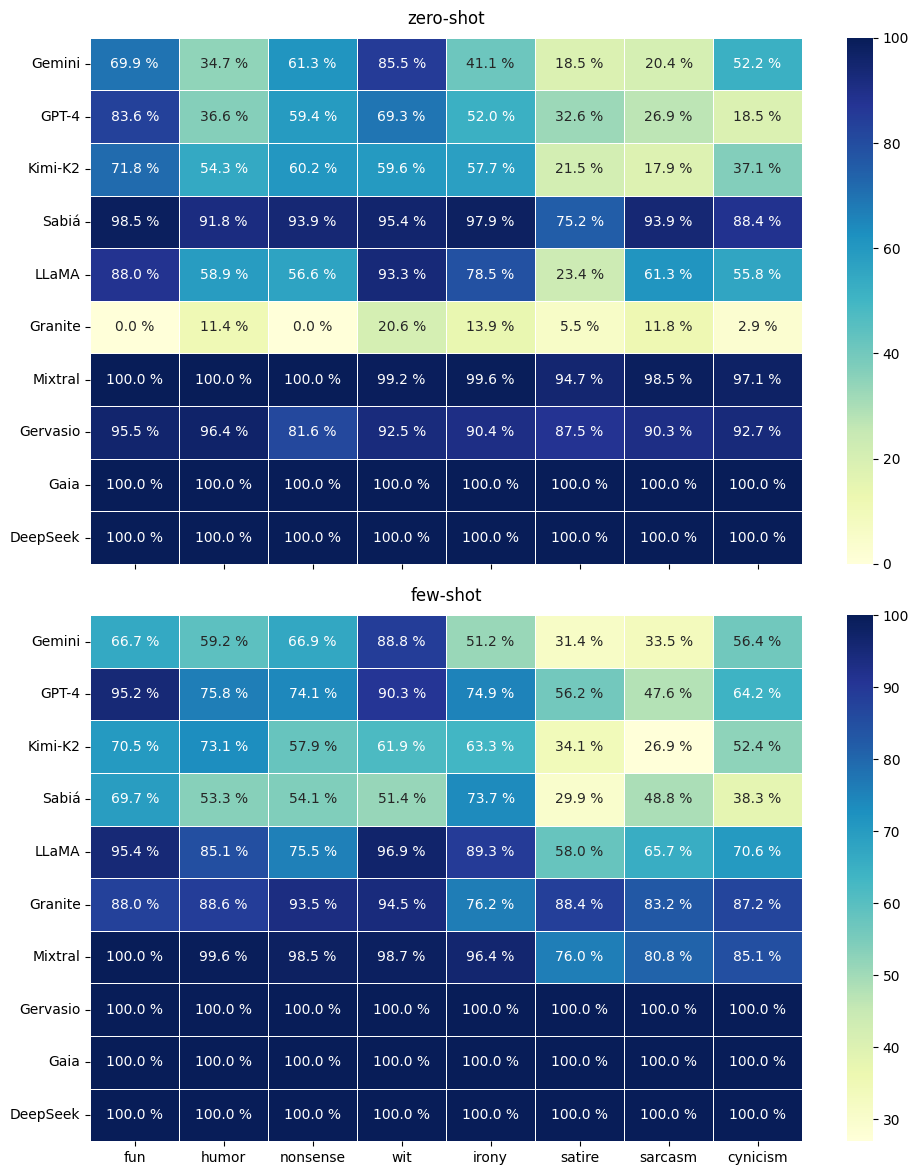

In [153]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

model_order = [
    'Gemini',
    'GPT-4',
    'Kimi-K2',
    'Sabiá',
    'LLaMA',
    'Granite',
    'Mixtral',
    'Gervasio',
    'Gaia',
    'DeepSeek'
]

comic_style_order = [
    'fun', 
    'humor', 
    'nonsense', 
    'wit', 
    'irony', 
    'satire', 
    'sarcasm',       
    'cynicism'
]

try:
    if 'df_comic_styles' not in locals() and 'df_comic_styles' not in globals():
        print("Simulando df_comic_styles e visus_path para demonstração.")
        data = {
            'scenario': ['A'] * 40 + ['B'] * 40,
            'model_name': (['Gemini', 'GPT-4'] * 2 + ['LLaMA', 'Granite'] * 2) * 10,
            'comic_style': (['fun', 'satire', 'irony', 'sarcasm'] * 2) * 5,
            'pred_label': [1, 0, 1, 1, 0, 1, 0, 0] * 10
        }
        df_comic_styles = pd.DataFrame(data)
        visus_path = '.'
except NameError:
    pass

df_counts_1 = df_comic_styles[df_comic_styles['pred_label'] == 1]
df_counts_1 = df_counts_1.groupby(['scenario', 'model_name', 'comic_style']).size().reset_index(name='count_correct')

df_counts_total = df_comic_styles.groupby(['scenario', 'model_name', 'comic_style']).size().reset_index(name='count_total')

df_merged = pd.merge(df_counts_1, df_counts_total, on=['scenario', 'model_name', 'comic_style'], how='right').fillna(0)

df_merged['percentage'] = (df_merged['count_correct'] / df_merged['count_total']) * 100

df_merged['model_name'] = pd.Categorical(df_merged['model_name'], categories=model_order, ordered=True)

df_merged['comic_style'] = pd.Categorical(df_merged['comic_style'], categories=comic_style_order, ordered=True)

pivot_data = df_merged.pivot_table(
    index='model_name',
    columns=['scenario', 'comic_style'],
    values='percentage',
    fill_value=0 
)

pivot_data = pivot_data.reindex(model_order)

scenarios = df_comic_styles['scenario'].unique()
fig, axes = plt.subplots(len(scenarios), 1, figsize=(10, 12), sharex=False, sharey=True) 
plt.suptitle('', fontsize=16, y=1.02)

if len(scenarios) == 1:
    axes = [axes]

for i, scenario in enumerate(scenarios):
    
    heatmap_data = pivot_data.xs(scenario, level='scenario', axis=1)
    
    sns.heatmap(
        heatmap_data,
        ax=axes[i],        
        annot=True,        
        fmt=".1f",         
        cmap="YlGnBu",     
        linewidths=.5,
        cbar_kws={'label': ''} 
    )
    
    for t in axes[i].texts: 
        t.set_text(t.get_text() + " %")
    
    axes[i].set_title(f'{scenario.lower()}', pad=10) 
    
    if i == len(scenarios) - 1:
        axes[i].set_xlabel('') 
        axes[i].tick_params(axis='x', rotation=0) 
    else:
        axes[i].set_xlabel('')
        axes[i].set_xticklabels([]) 
    
    axes[i].set_ylabel('') 

plt.tight_layout()
plt.savefig(os.path.join(visus_path, 'comic_styles_heatmap_by_scenario_vertical.png'), dpi=300, bbox_inches='tight')
plt.show()

In [154]:
df = df_comic_styles.copy()
rows = []

for (model, scenario, style), group in df.groupby(['model_name', 'scenario', 'comic_style']):
    y_true = group['true_label']
    y_pred = group['pred_label']
    
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    
    rows.append({
        'model_name': model,
        'scenario': scenario,
        'comic_style': style,
        'f1_0': report['0']['f1-score'],
        'f1_1': report['1']['f1-score'],
        'f1_macro': report['macro avg']['f1-score'],
        'balanced_accuracy': bal_acc
    })

results = pd.DataFrame(rows)

In [155]:
model_order = [
    'Gemini',
    'GPT-4',
    'Kimi-K2',
    'Sabiá',
    'LLaMA',
    'Granite', 
"""     'Gaia',
    'Mixtral',
    'DeepSeek',
    'Gervasio' """
]

results['model_name'] = pd.Categorical(results['model_name'], categories=model_order, ordered=True)

/tmp/ipykernel_6138/1466099502.py:10: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = results[results['scenario'] == scenario].pivot_table(
/tmp/ipykernel_6138/1466099502.py:10: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = results[results['scenario'] == scenario].pivot_table(
/tmp/ipykernel_6138/1466099502.py:10: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = results[results['scenario'] == scenario].pivot_table(
/tmp/ipykernel_6138/1466099502.py:10: FutureWarning: The default value

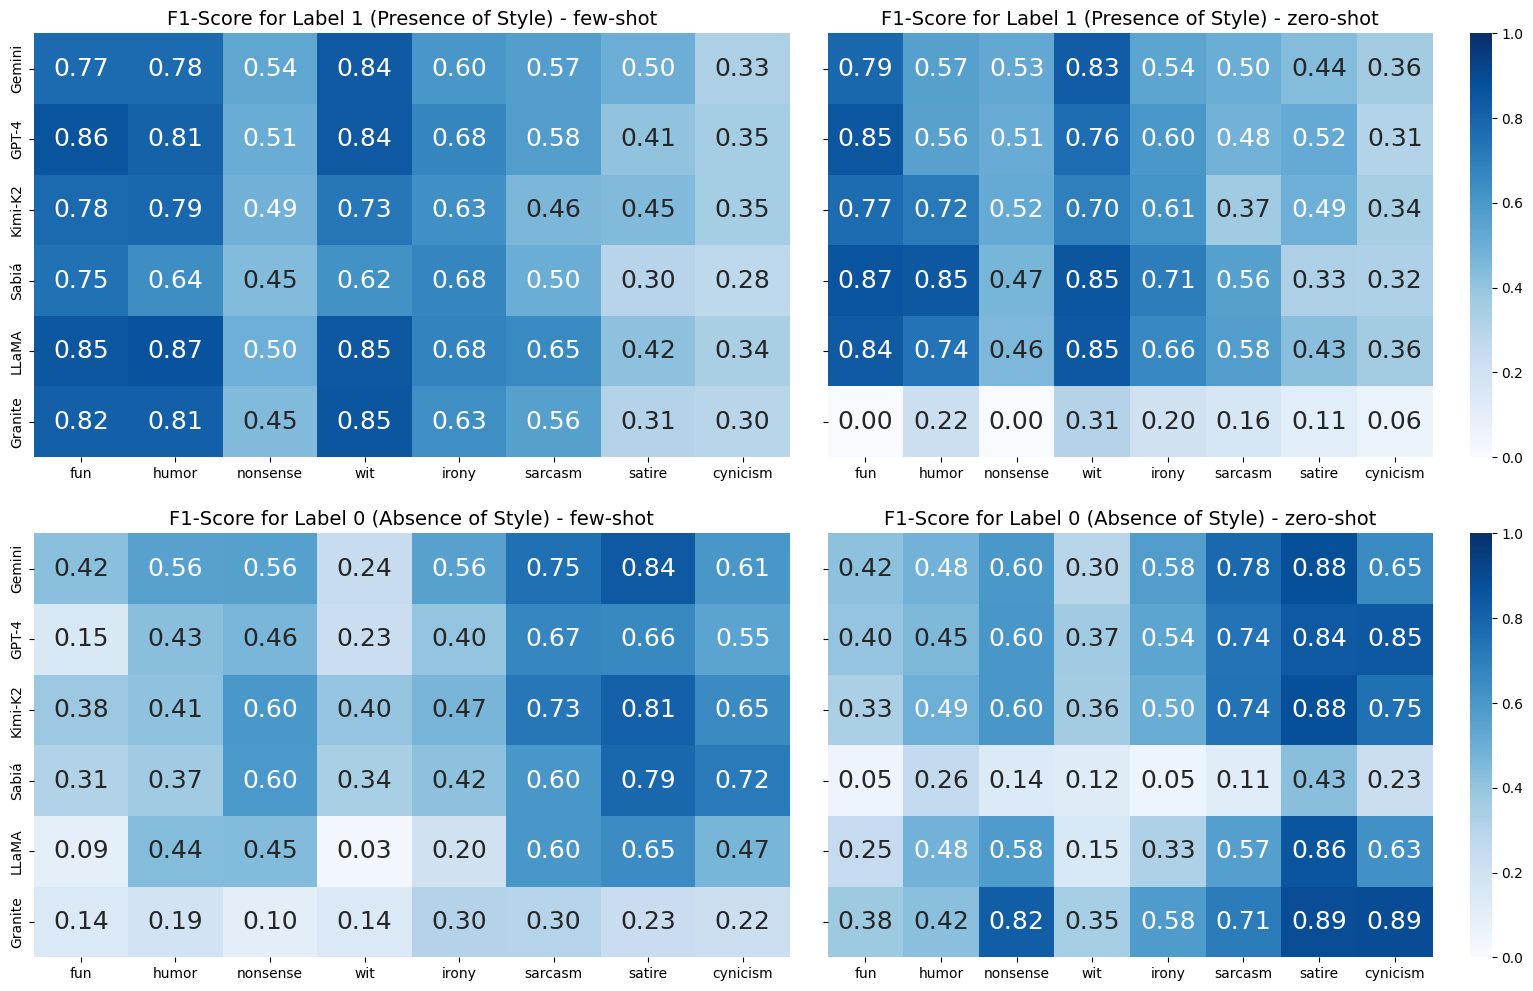

In [156]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 12), sharey=True)
f1_info = [('f1_1', 'Label 1 (Presence of Style)'), ('f1_0', 'Label 0 (Absence of Style)')]
scenarios = results['scenario'].unique()
style_order = ['fun', 'humor', 'nonsense', 'wit', 'irony', 'sarcasm', 'satire', 'cynicism']

for row_idx, (f1_class, title) in enumerate(f1_info):
    for col_idx, scenario in enumerate(scenarios):
        ax = axes[row_idx, col_idx]

        pivot = results[results['scenario'] == scenario].pivot_table(
            index='model_name', columns='comic_style', values=f1_class, aggfunc='mean'
        )
        
        pivot = pivot.reindex(columns=style_order)

        sns.heatmap(
            pivot,
            annot=True,
            cmap='Blues',
            vmin=0,
            vmax=1,
            ax=ax,
            fmt=".2f",
            annot_kws={'size': 18},
            cbar=(col_idx == 1)
        )
        
        ax.set_title(f'F1-Score for {title} - {scenario}', fontsize=14)
        ax.set_xlabel('', fontsize=16) 
        if col_idx == 0:
            ax.set_ylabel('', fontsize=16)
        else:
            ax.set_ylabel('')

        ax.tick_params(axis='x', labelsize=10, rotation=0)
        ax.tick_params(axis='y', labelsize=10)

plt.subplots_adjust(hspace=0.18, wspace=0.05)

plt.savefig(
    os.path.join(visus_path, "comic_styles_f1_individuals.png"), 
    dpi=300,
    bbox_inches='tight'
)
plt.show()

In [157]:
comic_styles = df_comic_styles['comic_style'].unique()
for style in comic_styles:
    df_name_worse = f"df_{style}_worse"
    df_name_better = f"df_{style}_better"
    globals()[df_name_worse] = df_comic_styles[(df_comic_styles['comic_style'] == style) & (df_comic_styles['is_correct'] == 0)]
    globals()[df_name_better] = df_comic_styles[(df_comic_styles['comic_style'] == style) & (df_comic_styles['is_correct'] == 1)]

##### Estilos Cômicos - Diferença entre as matrizes de co-ocorrência

In [158]:
original_data = pd.read_csv('./data/brazilian_ne_annotated_humorous_texts.csv')
original_data.head(2)

,video_url,video_title,publish_date,brazilian_state,text_origin,corrected_transcription,specific_contexts,punchlines,fun,humor,nonsense,wit,irony,satire,sarcasm,cynicism,joke_explanation
0,https://www.youtube.com/shorts/Xcve3ifSxWg?fea...,O CARA PUXOU A PISTOLA PRA MIM E EU... - EMERS...,"Dec 6, 2022",Ceará,Podcast,"Humorista: O cara me chamou falou aqui ó, puxo...","""Ovo virado"" é uma gíria pra indicar que algué...","Eu falei, vai buscar mais. Isso aí não dá nem ...",1,1,0,0,1,0,1,0,"O humorista narra uma cena tensa, porém cômica..."
1,https://www.youtube.com/shorts/QV80EKixLYc?fea...,Cachaçaaa😂😂 - Flavio Andradde - #shorts,"Oct 30, 2024",Pernambuco,Stand-up,Humorista: Quem já passou algumas coisas muito...,Record é uma rede de televisão comercial abert...,E ele tem a cara de pau de dizer era Cerveja!;...,1,1,0,1,0,1,1,0,O humorista desdenha da marca Crystal a partir...


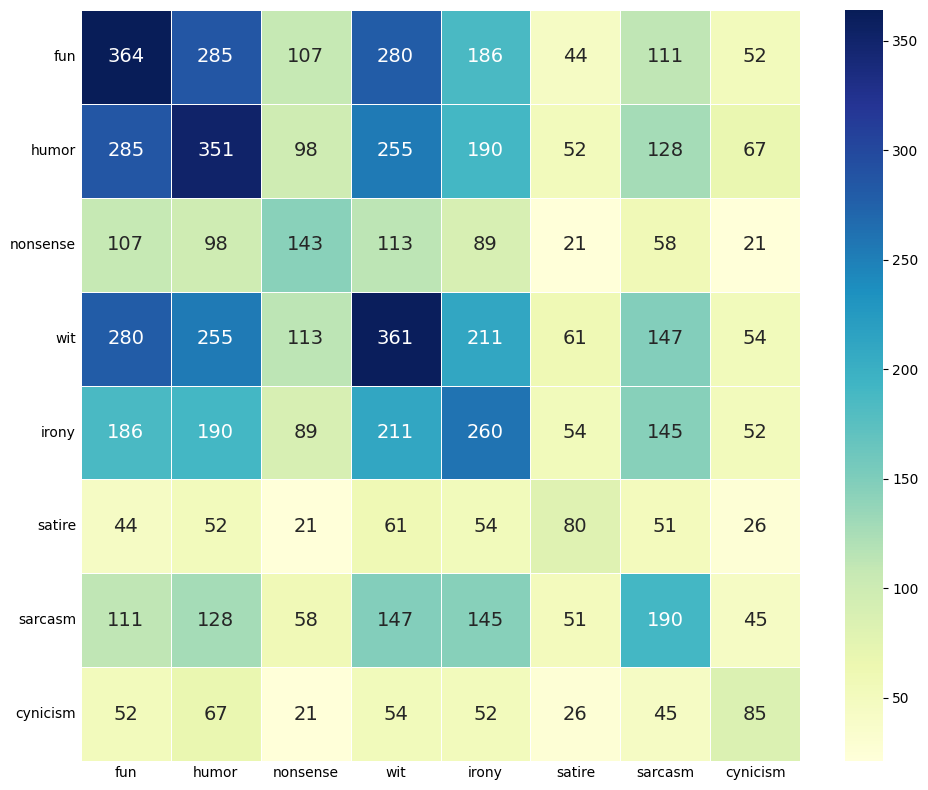

In [159]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

comedy_styles = [
    'fun', 'humor', 'nonsense', 'wit', 'irony', 'satire', 'sarcasm', 'cynicism'
]
data_styles = original_data[comedy_styles]
cooccurrence_matrix = data_styles.T.dot(data_styles)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cooccurrence_matrix, 
    annot=True, 
    fmt='d', 
    cmap='YlGnBu', 
    linewidths=.5,
    cbar_kws={'label': ''},
    annot_kws={'fontsize': 14}
)

ax = plt.gca() 

ax.tick_params(axis='y', which='both', length=0)
ax.tick_params(axis='x', which='both', length=0)

plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()

plt.savefig('./visualizations/comic_styles.png')

In [160]:
data_styles = original_data[comedy_styles]
cooccurrence_matrix = data_styles.T.dot(data_styles)

print("Matriz de Coocorrência:")
print(cooccurrence_matrix)

Matriz de Coocorrência:
          fun  humor  nonsense  wit  irony  satire  sarcasm  cynicism
fun       364    285       107  280    186      44      111        52
humor     285    351        98  255    190      52      128        67
nonsense  107     98       143  113     89      21       58        21
wit       280    255       113  361    211      61      147        54
irony     186    190        89  211    260      54      145        52
satire     44     52        21   61     54      80       51        26
sarcasm   111    128        58  147    145      51      190        45
cynicism   52     67        21   54     52      26       45        85


In [161]:
import pandas as pd
import numpy as np

comedy_styles = [
    'fun', 'humor', 'nonsense', 'wit', 'irony', 'satire', 'sarcasm', 'cynicism'
]
original_data_styles = original_data[comedy_styles]

ORIGINAL_COOCURRENCE_MATRIX = original_data_styles.T.dot(original_data_styles)
ORIGINAL_COOCURRENCE_MATRIX = pd.DataFrame(
    ORIGINAL_COOCURRENCE_MATRIX, 
    index=comedy_styles, 
    columns=comedy_styles
)

difference_matrices = {}

for (scenario, model_name), group in df_comic_styles.groupby(['scenario', 'model_name']):
    key = f"{scenario}_{model_name}"
    
    pivot_df = group.pivot_table(
        index='video_url', 
        columns='comic_style', 
        values='pred_label', 
        aggfunc='max'
    ).fillna(0)

    data_pred_styles = pivot_df.reindex(columns=comedy_styles, fill_value=0)
    
    pred_cooccurrence_matrix = data_pred_styles.T.dot(data_pred_styles)
    difference_matrix = pred_cooccurrence_matrix - ORIGINAL_COOCURRENCE_MATRIX
    difference_matrices[key] = difference_matrix

Iniciando a geração dos Mapas de Calor, excluindo os modelos: ['Gaia', 'Mixtral', 'DeepSeek', 'Gervasio']
------------------------------------------------------------
⏩ Ignorando few-shot_DeepSeek (Modelo na lista de exclusão).
✨ Gerando Mapa de Calor para: few-shot_GPT-4


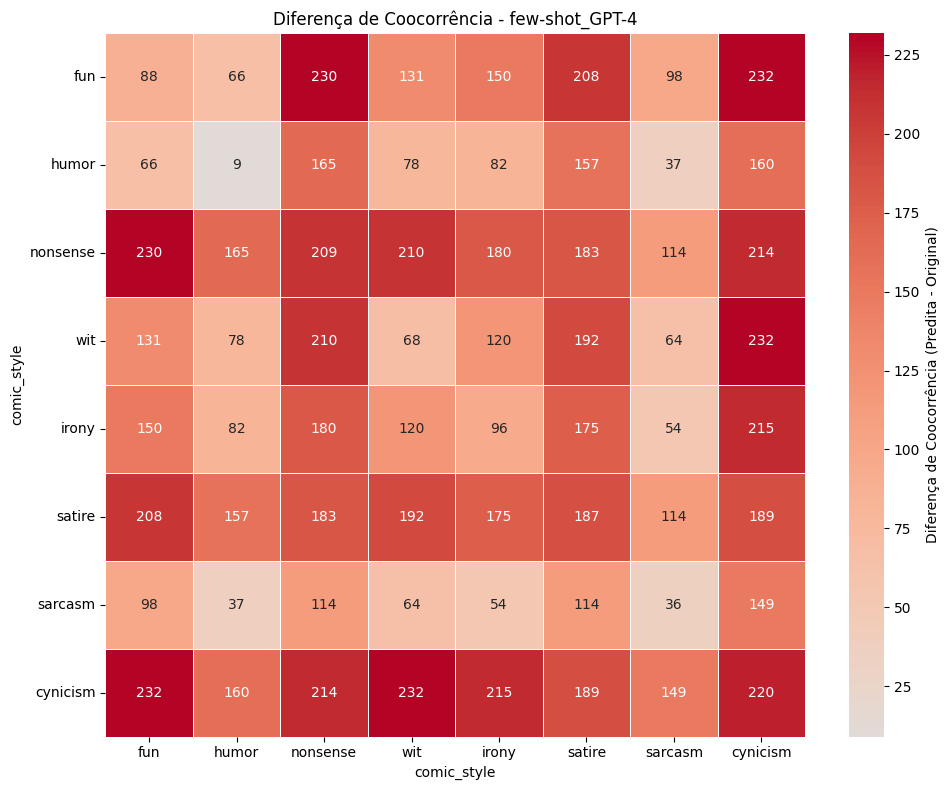

⏩ Ignorando few-shot_Gaia (Modelo na lista de exclusão).
✨ Gerando Mapa de Calor para: few-shot_Gemini


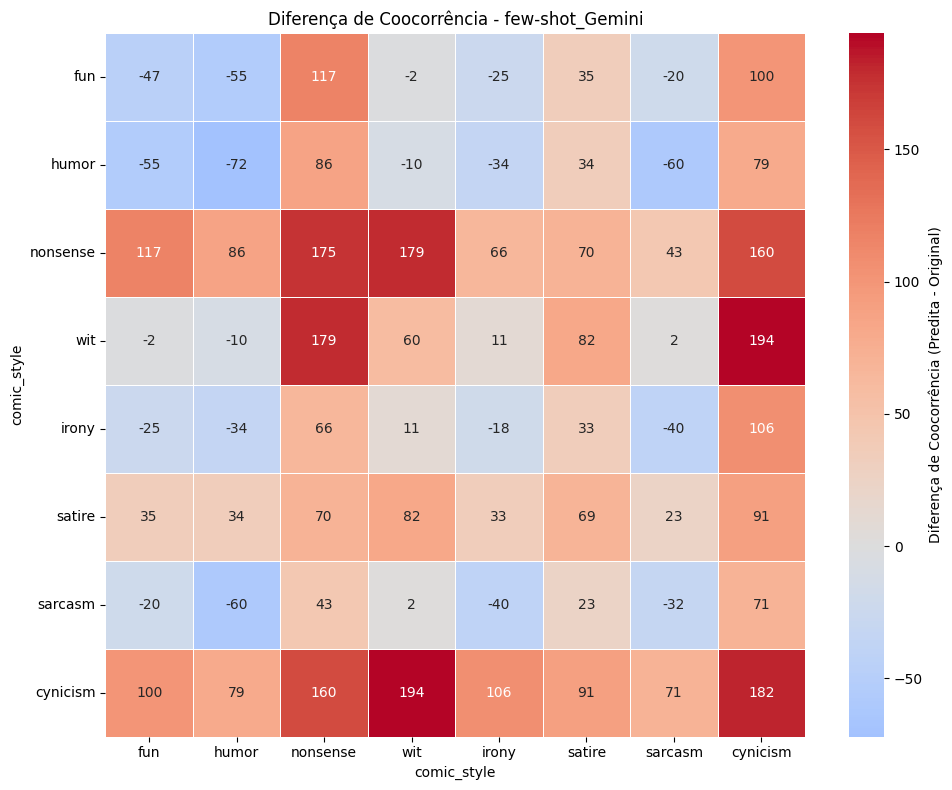

⏩ Ignorando few-shot_Gervasio (Modelo na lista de exclusão).
✨ Gerando Mapa de Calor para: few-shot_Granite


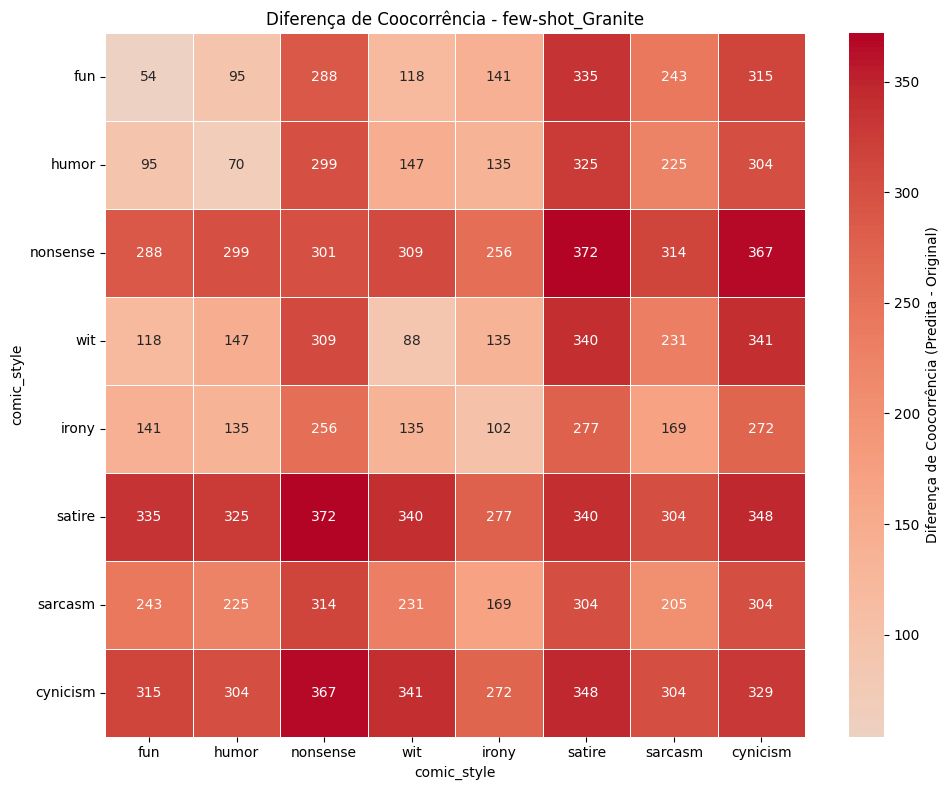

✨ Gerando Mapa de Calor para: few-shot_Kimi-K2


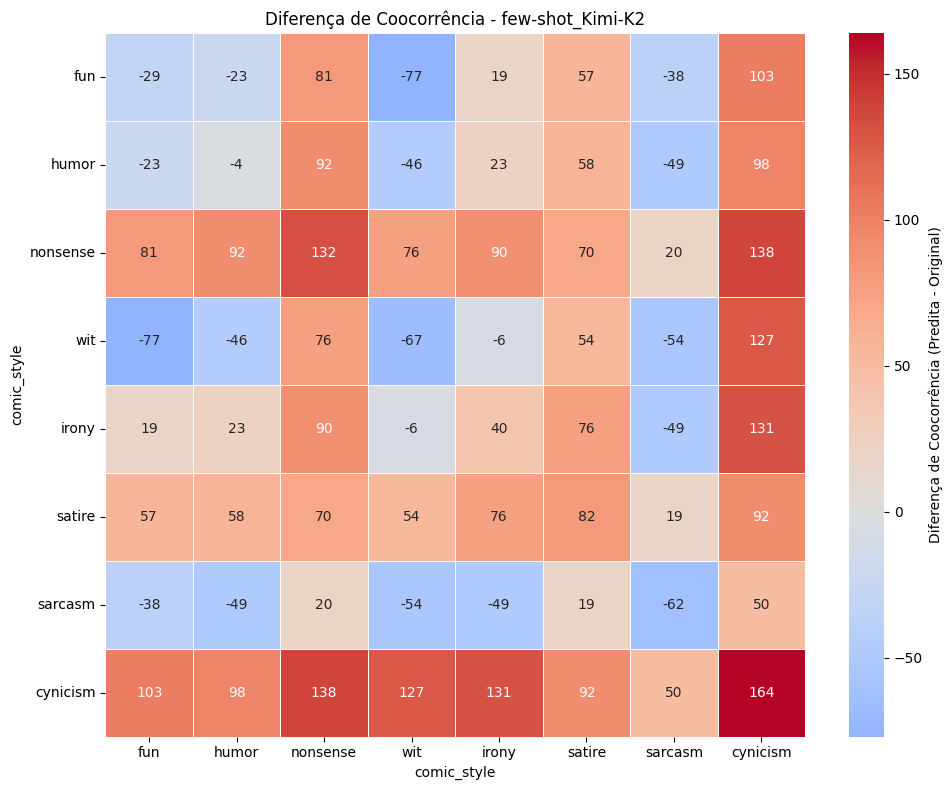

✨ Gerando Mapa de Calor para: few-shot_LLaMA


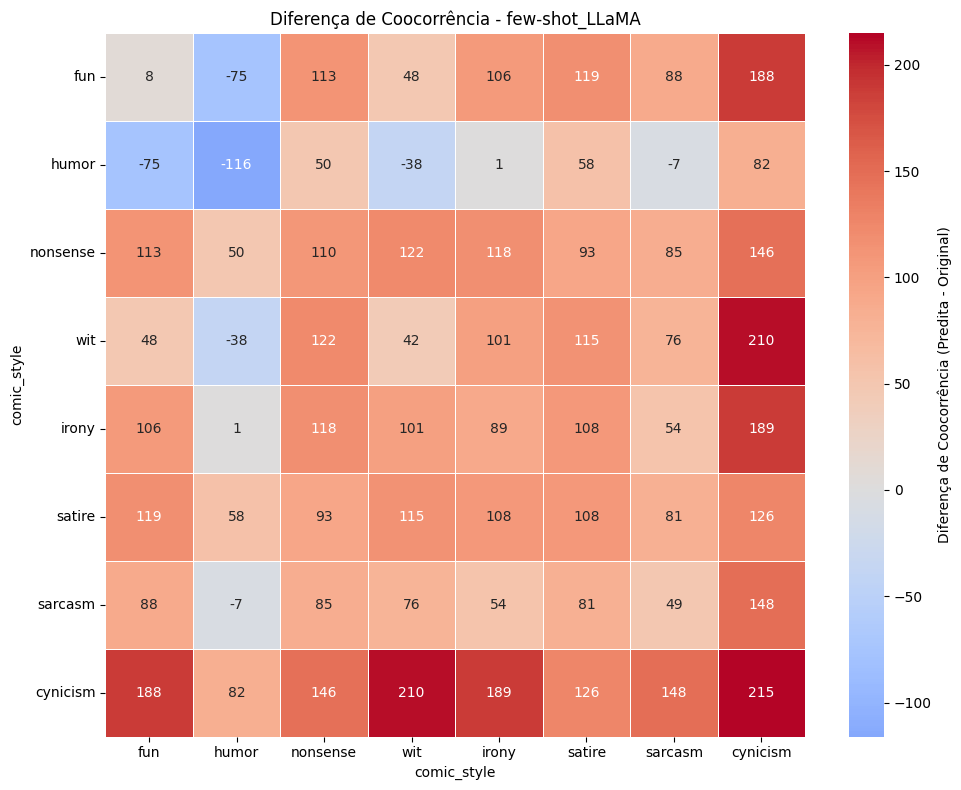

⏩ Ignorando few-shot_Mixtral (Modelo na lista de exclusão).
✨ Gerando Mapa de Calor para: few-shot_Sabiá


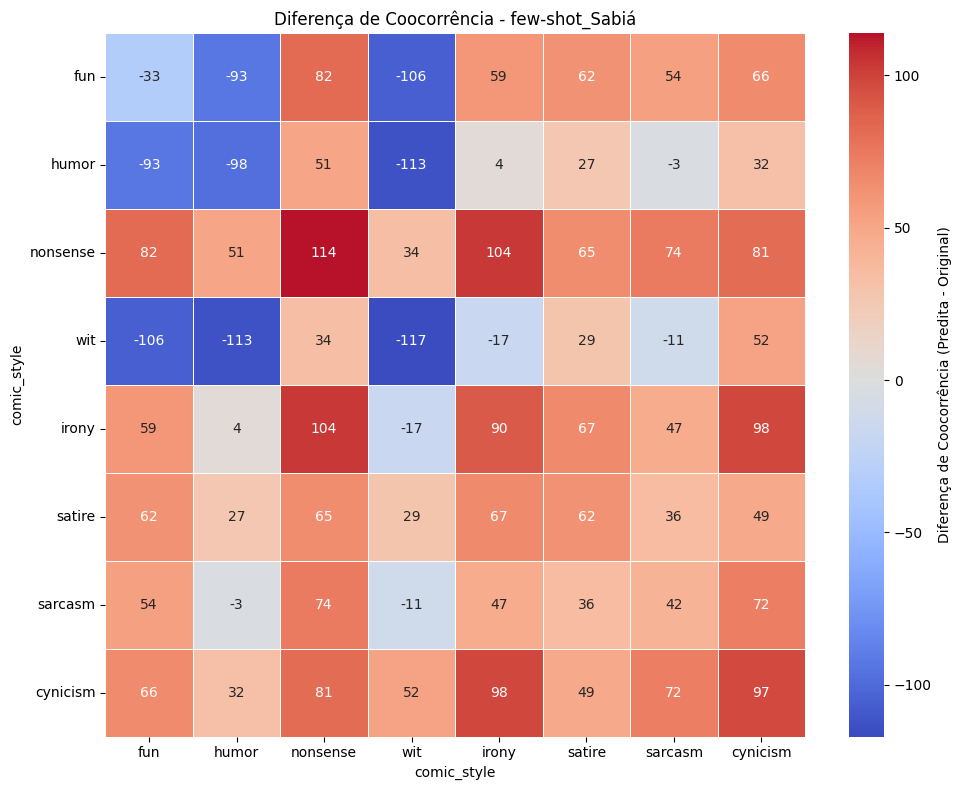

⏩ Ignorando zero-shot_DeepSeek (Modelo na lista de exclusão).
✨ Gerando Mapa de Calor para: zero-shot_GPT-4


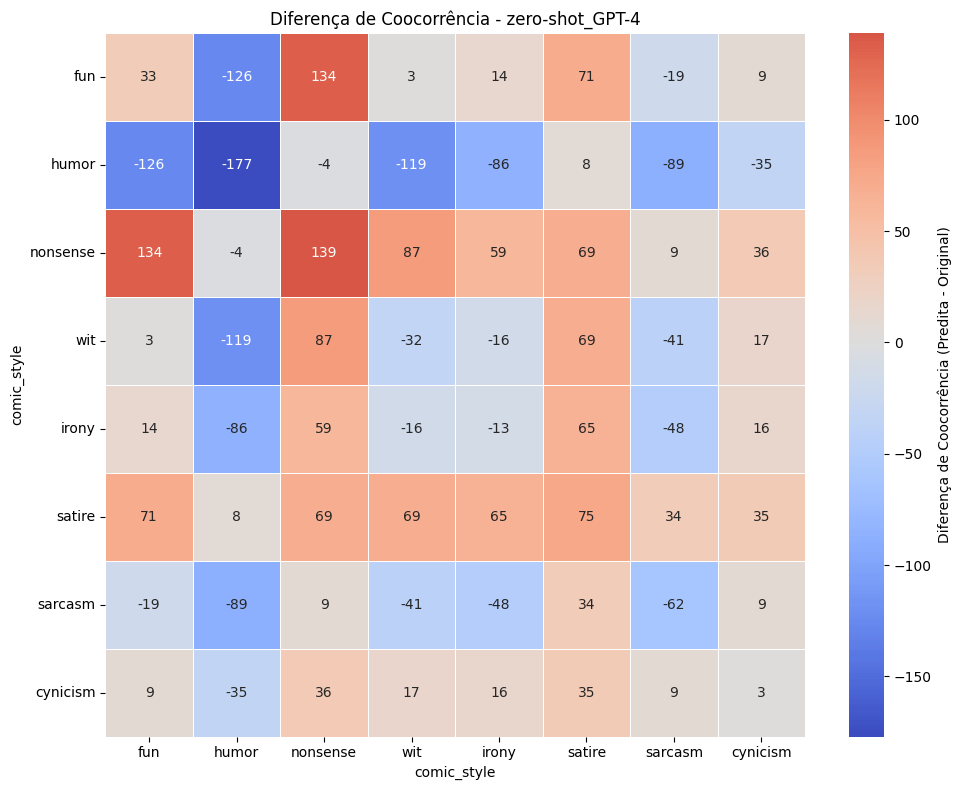

⏩ Ignorando zero-shot_Gaia (Modelo na lista de exclusão).
✨ Gerando Mapa de Calor para: zero-shot_Gemini


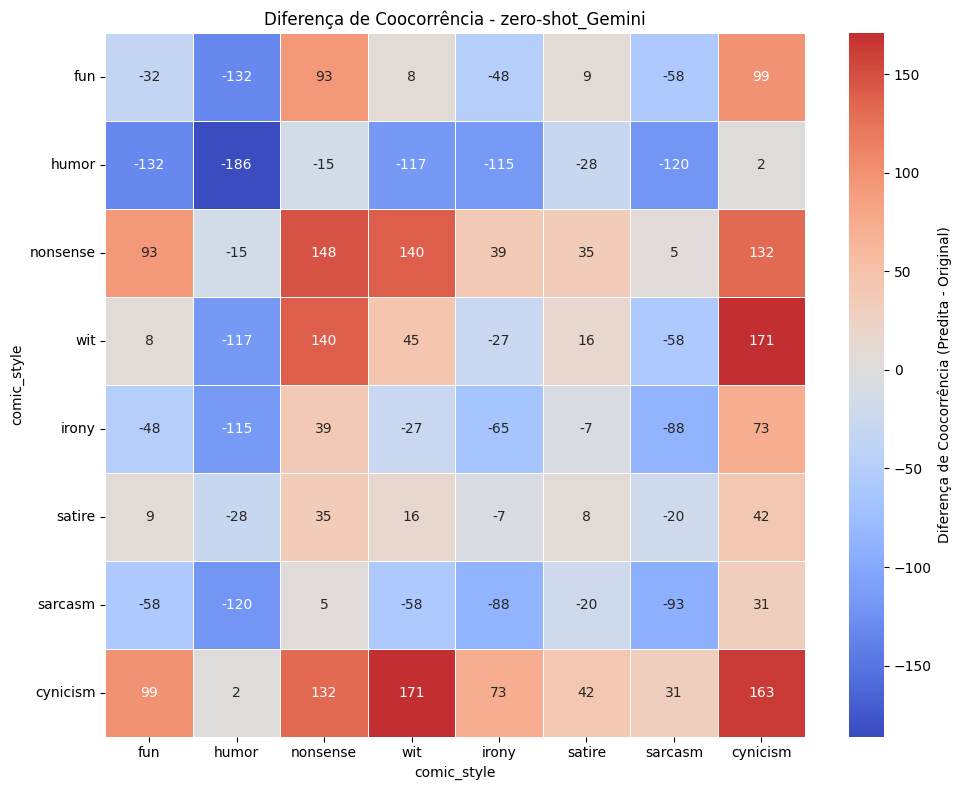

⏩ Ignorando zero-shot_Gervasio (Modelo na lista de exclusão).
✨ Gerando Mapa de Calor para: zero-shot_Granite


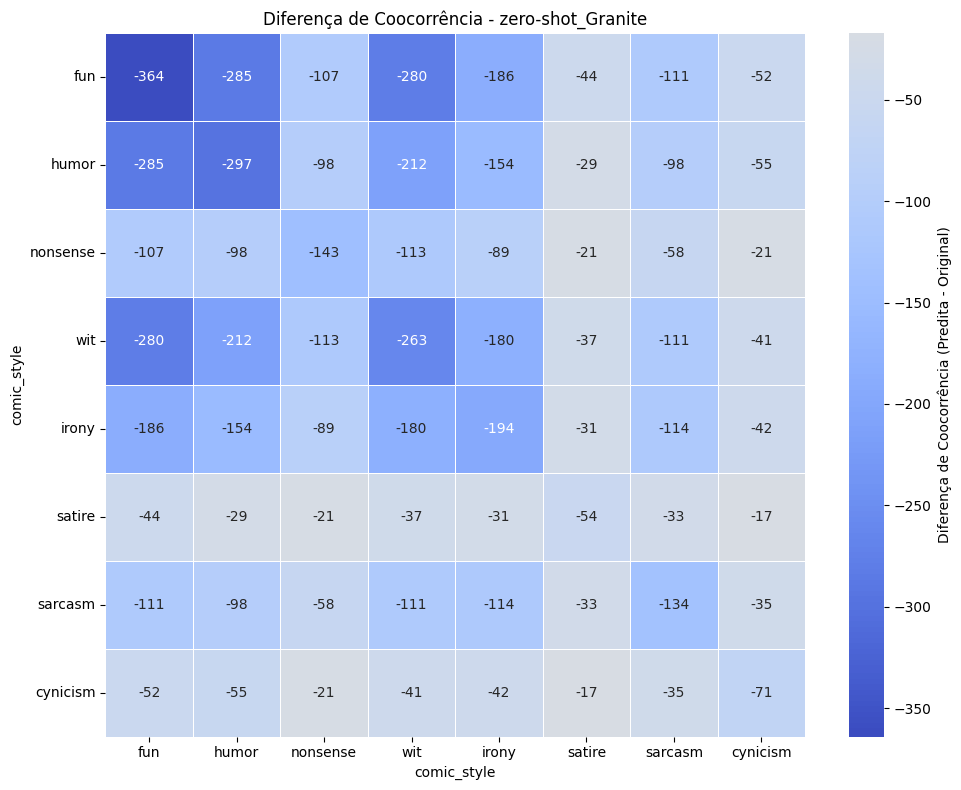

✨ Gerando Mapa de Calor para: zero-shot_Kimi-K2


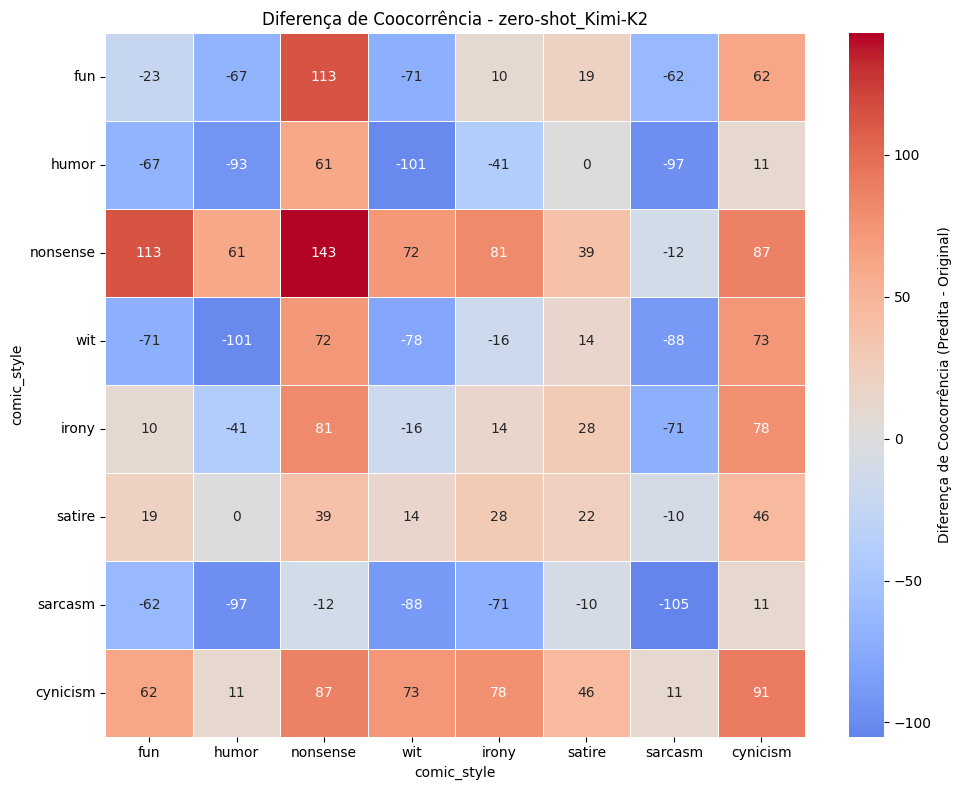

✨ Gerando Mapa de Calor para: zero-shot_LLaMA


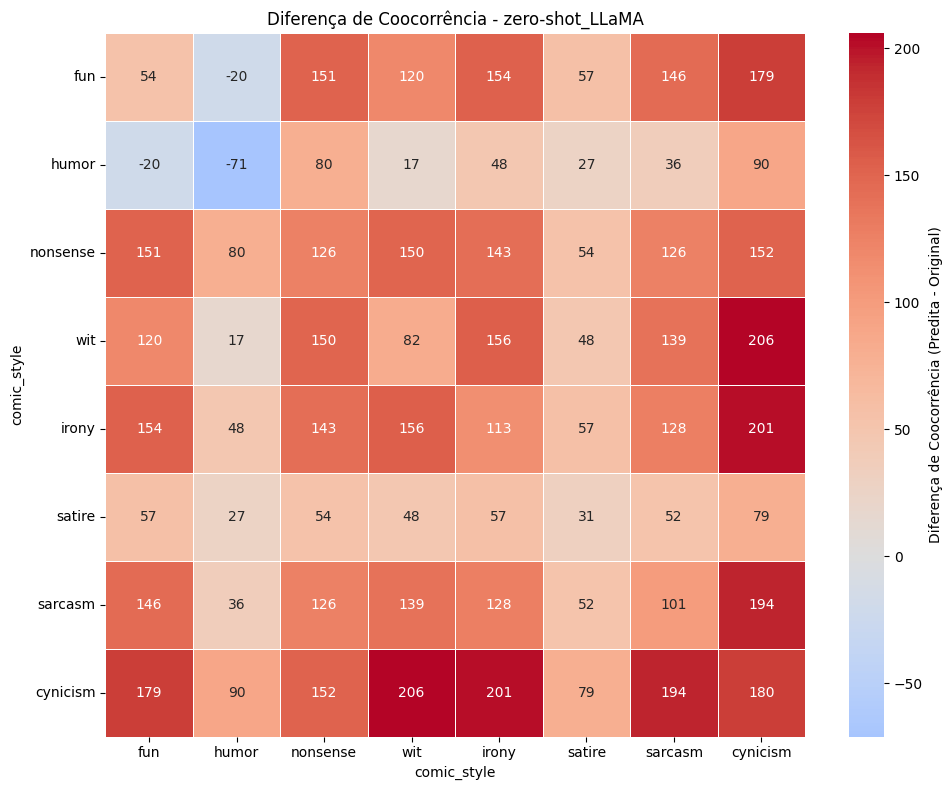

⏩ Ignorando zero-shot_Mixtral (Modelo na lista de exclusão).
✨ Gerando Mapa de Calor para: zero-shot_Sabiá


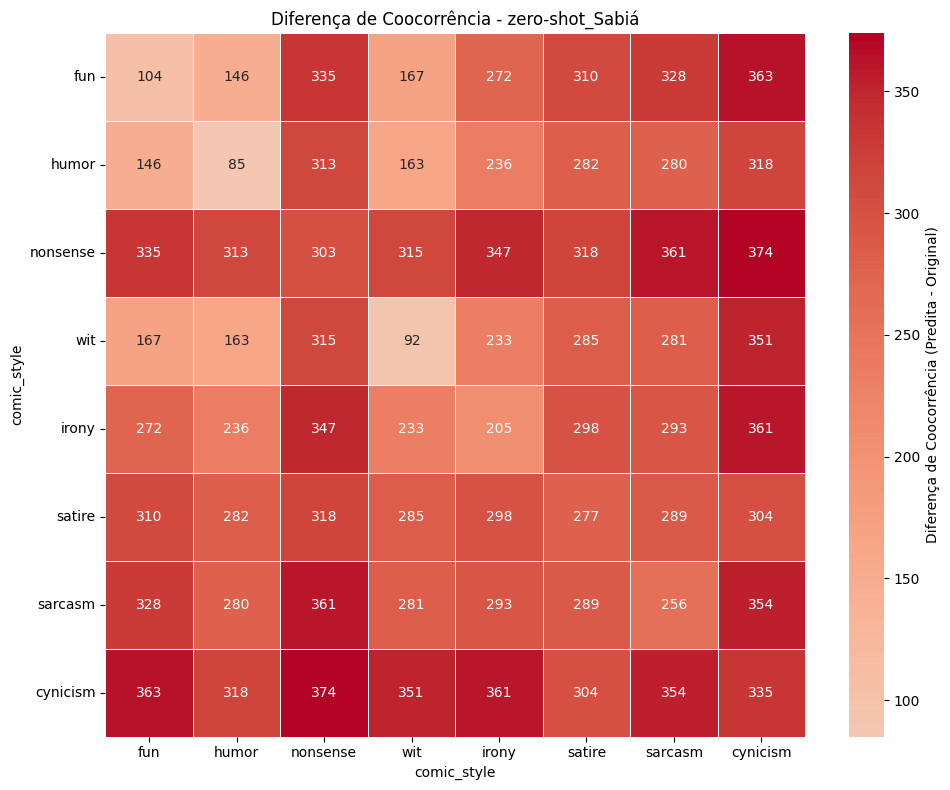

In [165]:
import matplotlib.pyplot as plt
import seaborn as sns

# Lista dos modelos a serem ignorados
models_to_ignore = ['Gaia', 'Mixtral', 'DeepSeek', 'Gervasio']

print("Iniciando a geração dos Mapas de Calor, excluindo os modelos:", models_to_ignore)
print("-" * 60)

for chave, matrix in difference_matrices.items():
    
    # 1. Verificação Condicional (mantida do código anterior)
    if any(model in chave for model in models_to_ignore):
        print(f"⏩ Ignorando {chave} (Modelo na lista de exclusão).")
        continue 

    print(f"✨ Gerando Mapa de Calor para: {chave}")
    
    # 2. 🚨 CORREÇÃO DO ERRO: Converte a matriz para tipo inteiro (int)
    # Isso garante que fmt='d' funcione.
    corrected_matrix = matrix.astype(int)

    # 3. Geração do Mapa de Calor (Heatmap)
    plt.figure(figsize=(10, 8))
    
    sns.heatmap(
        corrected_matrix,  # Usamos a matriz convertida
        annot=True, 
        fmt='d',           # 'd' agora funciona com inteiros
        cmap='coolwarm', 
        center=0,        
        linewidths=.5, 
        cbar_kws={'label': 'Diferença de Coocorrência (Predita - Original)'}
    )
    
    plt.title(f'Diferença de Coocorrência - {chave}')
    plt.xticks(rotation=0) 
    plt.yticks(rotation=0)
    plt.tight_layout()
    
    # Salvar a figura 
    plt.savefig(f'./visualizations/difference_matrix_{chave}.png')
    
    plt.show()

##### Humor Reasoning

In [ ]:
df_explanations_worse = df_texts_explanations[df_texts_explanations['agreement_level'] <= WORSE_EXPLANATIONS_THRESHOLD]
df_explanations_better = df_texts_explanations[df_texts_explanations['agreement_level'] >= BETTER_EXPLANATIONS_THRESHOLD]

In [ ]:
expl_worse_summary = df_explanations_worse.groupby(['model_name', 'scenario']).agg({
    'agreement_level': ['count', 'mean']
}).round(3)

expl_worse_summary.columns = ['count', 'agreement_level']
expl_worse_summary = expl_worse_summary.reset_index()
expl_worse_summary = expl_worse_summary.sort_values(['model_name', 'scenario'])

print(expl_worse_summary)

                             model_name   scenario  count  agreement_level
0             deepseek-r1-0528-qwen3-8b   few-shot    359            1.471
1             deepseek-r1-0528-qwen3-8b  zero-shot    256            1.625
2                      gemini-2.5-flash   few-shot     70            1.886
3                      gemini-2.5-flash  zero-shot     31            1.871
4              gemma-3-gaia-pt-br-4b-it   few-shot    207            1.749
5              gemma-3-gaia-pt-br-4b-it  zero-shot    164            1.701
6   gervasio-7b-portuguese-ptbr-decoder   few-shot    430            1.300
7   gervasio-7b-portuguese-ptbr-decoder  zero-shot    435            1.186
8                                 gpt-4   few-shot     81            1.864
9                                 gpt-4  zero-shot     72            1.875
10              granite-3-3-8b-instruct   few-shot    161            1.739
11              granite-3-3-8b-instruct  zero-shot    147            1.789
12                       

In [ ]:
expl_better_summary = df_explanations_better.groupby(['model_name', 'scenario']).agg({
    'agreement_level': ['count', 'mean']
}).round(3)

expl_better_summary.columns = ['count', 'agreement_level']
expl_better_summary = expl_better_summary.reset_index()
expl_better_summary = expl_better_summary.sort_values(['model_name', 'scenario'])

print(expl_better_summary)

                             model_name   scenario  count  agreement_level
0             deepseek-r1-0528-qwen3-8b   few-shot     92            4.413
1             deepseek-r1-0528-qwen3-8b  zero-shot    176            4.398
2                      gemini-2.5-flash   few-shot    398            4.756
3                      gemini-2.5-flash  zero-shot    433            4.875
4              gemma-3-gaia-pt-br-4b-it   few-shot    226            4.588
5              gemma-3-gaia-pt-br-4b-it  zero-shot    262            4.523
6   gervasio-7b-portuguese-ptbr-decoder   few-shot     37            4.486
7   gervasio-7b-portuguese-ptbr-decoder  zero-shot     29            4.517
8                                 gpt-4   few-shot    379            4.702
9                                 gpt-4  zero-shot    384            4.797
10              granite-3-3-8b-instruct   few-shot    284            4.623
11              granite-3-3-8b-instruct  zero-shot    295            4.637
12                       